### Adarsh Yadav
### Roll No:23107001
### Class:AIDS-A

### Project_title: Implementation of a Brain Tumor Classification & Localization Prototype Using TensorFlow and Evaluation of Its Performance on an MRI Dataset.


In [ ]:
import os
import json

# 1. Create the hidden Kaggle folder
os.makedirs('/root/.kaggle', exist_ok=True)

# 2. Write your credentials directly into the system
kaggle_creds = {
  "username": "ai001adarshyadav",  # <--- Replace this! (e.g., "johndoe")
  "key": "KGAT_6ee6b33c6065c20922588b011ae044f4"             # <--- Replace this! (e.g., "6ee6b33c...")
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
  json.dump(kaggle_creds, f)

# 3. Secure the file (Kaggle requires this)
os.chmod('/root/.kaggle/kaggle.json', 600)
print("✅ Credentials locked in. Starting download...")

# 4. Download and unzip
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d dataset

# 5. Show us what is in the folder now!
!ls -lh

✅ Credentials locked in. Starting download...
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
 78% 122M/157M [00:00<00:00, 1.24GB/s]
100% 157M/157M [00:00<00:00, 1.02GB/s]
total 158M
-rw-r--r-- 1 root root 158M Feb 13 19:26 brain-tumor-mri-dataset.zip
drwxr-xr-x 4 root root 4.0K Mar  5 19:36 dataset
drwxr-xr-x 1 root root 4.0K Feb  6 14:31 sample_data


In [ ]:
!ls -lh

total 158M
-rw-r--r-- 1 root root 158M Feb 13 19:26 brain-tumor-mri-dataset.zip
drwxr-xr-x 4 root root 4.0K Mar  5 19:36 dataset
drwxr-xr-x 1 root root 4.0K Feb  6 14:31 sample_data


In [ ]:
import os

# Define the path to where we unzipped the data
base_dir = 'dataset'

# Loop through both the Training and Testing folders
for split in ['Training', 'Testing']:
    print(f"\n--- {split} Set ---")
    split_dir = os.path.join(base_dir, split)

    # Count the images in each tumor category
    if os.path.exists(split_dir):
        for category in sorted(os.listdir(split_dir)):
            category_dir = os.path.join(split_dir, category)
            if os.path.isdir(category_dir):
                num_images = len(os.listdir(category_dir))
                print(f"{category}: {num_images} images")
    else:
        print(f"Directory {split_dir} not found. Double-check the unzip step!")


--- Training Set ---
glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images

--- Testing Set ---
glioma: 400 images
meningioma: 400 images
notumor: 400 images
pituitary: 400 images


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Define standard image size and batch size
IMG_SIZE = (224, 224) # Resizing all MRIs to 224x224 pixels
BATCH_SIZE = 32       # Feeding the AI 32 images at a time

train_dir = 'dataset/Training'
test_dir = 'dataset/Testing'

# 2. Load the Training Data
print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# 3. Load the Testing Data
print("\nLoading Testing Data:")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# 4. Save the class names for later
class_names = train_dataset.class_names
print(f"\n✅ Classes found: {class_names}")

Loading Training Data:
Found 5600 files belonging to 4 classes.

Loading Testing Data:
Found 1600 files belonging to 4 classes.

✅ Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
from tensorflow.keras import layers, models

# 1. Initialize the Neural Network
model = models.Sequential([
    # Step 1: Normalize the images (scale pixel values from 0-255 down to 0-1)
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # Step 2: First Convolutional Block (Looking for basic edges)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Step 3: Second Convolutional Block (Looking for textures/shapes)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Step 4: Third Convolutional Block (Looking for complex tumor features)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Step 5: Flatten the 2D images into a 1D list for the final decision maker
    layers.Flatten(),

    # Step 6: Fully Connected "Dense" Layer (The decision maker)
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Drops 50% of connections randomly to prevent "memorizing" the data (overfitting)

    # Step 7: Output Layer (4 neurons for our 4 classes: Glioma, Meningioma, No Tumor, Pituitary)
    layers.Dense(4, activation='softmax')
])

# Print the blueprint of our AI
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# 1. Compile the Model (Give it the rules for learning)
model.compile(
    optimizer='adam', # The standard, highly efficient learning algorithm
    loss='sparse_categorical_crossentropy', # How it calculates its mistakes
    metrics=['accuracy'] # We want to track how accurate it is
)

# 2. Train the Model!
EPOCHS = 20 # An "epoch" is one full pass through the entire dataset.

print(f"🚀 Starting training for {EPOCHS} epochs... This might take a few minutes!")

history = model.fit(
    train_dataset,
    validation_data=test_dataset, # We test it on unseen data after every round
    epochs=EPOCHS
)

print("✅ Training Complete!")

🚀 Starting training for 20 epochs... This might take a few minutes!
Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 84ms/step - accuracy: 0.5607 - loss: 1.1012 - val_accuracy: 0.7613 - val_loss: 0.7606
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.8140 - loss: 0.4884 - val_accuracy: 0.7856 - val_loss: 0.8638
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.8729 - loss: 0.3452 - val_accuracy: 0.8325 - val_loss: 0.8327
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.9028 - loss: 0.2682 - val_accuracy: 0.8369 - val_loss: 0.9067
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.9350 - loss: 0.1726 - val_accuracy: 0.8406 - val_loss: 1.1608
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.9501 - loss: 0.1326 - val_accuracy: 0.8631 - val_loss: 0.9970
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.9595 - loss: 0.1164 - val_accuracy: 0.8737 - val_loss: 1.0609
Epoch 8/20
175/175 ━━━

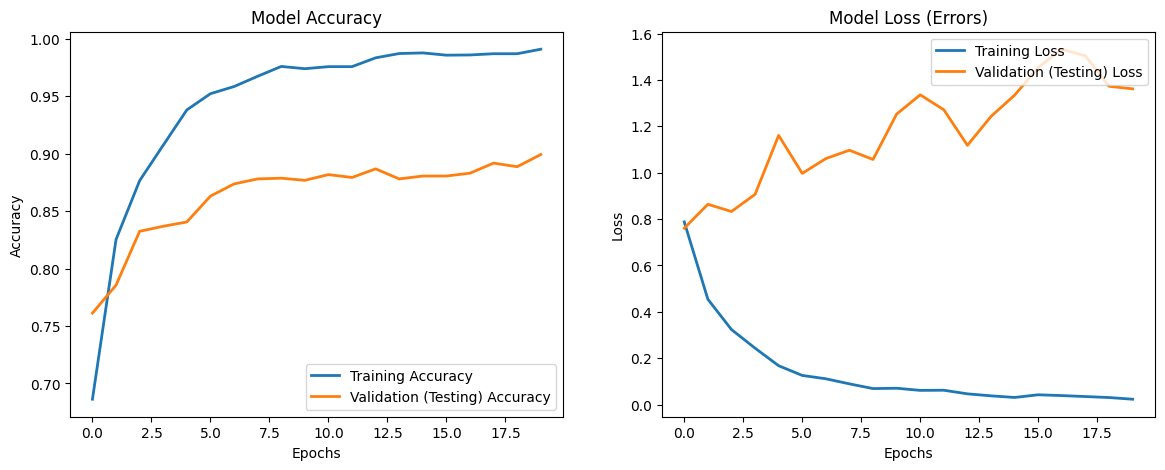

In [ ]:
import matplotlib.pyplot as plt

# Extract the data from our training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get the number of epochs that actually ran
epochs_range = range(len(acc))

# Create the plots
plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation (Testing) Accuracy', linewidth=2)
plt.legend(loc='lower right')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Plot 2: Loss (Errors)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation (Testing) Loss', linewidth=2)
plt.legend(loc='upper right')
plt.title('Model Loss (Errors)')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

In [ ]:
# Save the model architecture, weights, and training configuration
model.save('brain_tumor_model.h5')

print("✅ Model saved successfully as 'brain_tumor_model.h5'!")

✅ Model saved successfully as 'brain_tumor_model.h5'!


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.cm as cm

# 1. Find the last convolutional layer in our model automatically
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print(f"✅ Found the last Conv2D layer: {last_conv_layer_name}")

# 2. The Grad-CAM Algorithm
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a sub-model that outputs both the last conv layer activations and the final predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Calculate gradients of the predicted class with respect to the output feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Average the gradients spatially
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel by "how important" it is, then sum them up to get the heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap between 0 and 1 for visualization
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

print("✅ Grad-CAM engine is ready!")

✅ Found the last Conv2D layer: conv2d_2
✅ Grad-CAM engine is ready!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


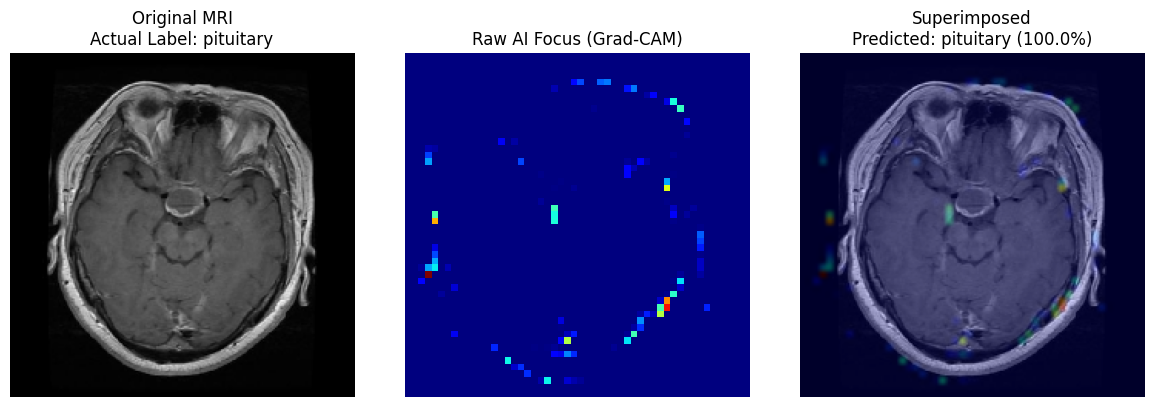

In [ ]:
import random
import matplotlib.cm as cm
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# 1. Pick a random image from the Testing folder
test_dir = 'dataset/Testing'
# We will randomly select one of the tumor classes, then a random image inside it
random_class = random.choice([c for c in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, c))])
random_image_name = random.choice(os.listdir(os.path.join(test_dir, random_class)))
img_path = os.path.join(test_dir, random_class, random_image_name)

# 2. Load and format the image for the model
img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img)
img_array_batch = np.expand_dims(img_array, axis=0) # Add a batch dimension

# 3. Get the AI's prediction
predictions = model.predict(img_array_batch)
predicted_class_idx = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_idx]
confidence = np.max(predictions[0]) * 100

# 4. Generate the raw heatmap using our engine
heatmap = make_gradcam_heatmap(img_array_batch, model, last_conv_layer_name)

# 5. Colorize and superimpose the heatmap onto the original MRI
heatmap_rescaled = np.uint8(255 * heatmap)
jet = cm.jet(np.arange(256))[:, :3]
jet_heatmap = jet[heatmap_rescaled]

jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img_array.shape[1], img_array.shape[0]))
jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

superimposed_img = jet_heatmap * 0.4 + img_array # 0.4 is the heatmap opacity
superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

# 6. Display the beautiful results!
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Original MRI\nActual Label: {random_class}")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Raw AI Focus (Grad-CAM)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title(f"Superimposed\nPredicted: {predicted_class_name} ({confidence:.1f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.cm as cm

# 1. Find the last convolutional layer
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print(f"✅ Found the last Conv2D layer: {last_conv_layer_name}")

# 2. The Keras-3 Compatible Grad-CAM Algorithm
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # FIX: We use model.layers[-1].output instead of model.output to avoid Keras 3 errors
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.layers[-1].output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

print("✅ Grad-CAM engine is patched and ready!")

✅ Found the last Conv2D layer: conv2d_2
✅ Grad-CAM engine is patched and ready!


In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
import cv2
from PIL import Image
import matplotlib.cm as cm

# --- Streamlit Page Setup ---
st.set_page_config(page_title="Brain Tumor Detector", page_icon="🧠", layout="centered")
st.title("🧠 Brain Tumor MRI Classifier & XAI")
st.write("Upload an MRI scan to detect the tumor class and view the AI's focus area (Grad-CAM).")

# --- Load Model & Setup ---
@st.cache_resource
def load_model():
    return tf.keras.models.load_model('brain_tumor_model.h5')

model = load_model()
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# --- Grad-CAM Function ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.layers[-1].output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# --- Find Last Conv Layer ---
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

# --- File Uploader ---
uploaded_file = st.file_uploader("Choose an MRI image...", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:
    # 1. Process the Image
    image = Image.open(uploaded_file).convert('RGB')
    img_resized = image.resize((224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img_resized)
    img_array_batch = np.expand_dims(img_array, axis=0)

    # 2. Make Prediction
    predictions = model.predict(img_array_batch)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100

    st.subheader(f"Prediction: **{predicted_class.capitalize()}** ({confidence:.2f}% Confidence)")

    # 3. Generate Heatmap
    heatmap = make_gradcam_heatmap(img_array_batch, model, last_conv_layer_name)

    # 4. Superimpose
    heatmap_rescaled = np.uint8(255 * heatmap)
    jet = cm.jet(np.arange(256))[:, :3]
    jet_heatmap = jet[heatmap_rescaled]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img_array.shape[1], img_array.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
    superimposed_img = jet_heatmap * 0.4 + img_array
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    # 5. Display Results side-by-side
    col1, col2 = st.columns(2)
    with col1:
        st.image(image, caption="Original MRI", use_container_width=True)
    with col2:
        st.image(superimposed_img, caption="AI Focus (Grad-CAM)", use_container_width=True)

Writing app.py


In [ ]:
# 1. Install Streamlit and localtunnel (to create the public link)
!pip install -q streamlit
!npm install localtunnel

# 2. Grab your Colab machine's IP address (You will need to copy the number this prints!)
import urllib
print("👉 COPY THIS IP ADDRESS: ", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

# 3. Run Streamlit in the background and link it to localtunnel
!streamlit run app.py & npx localtunnel --port 8501

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 127.7 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
added 22 packages in 2s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧👉 COPY THIS IP ADDRESS:  35.240.191.203
⠙⠹

your url is: https://some-pets-cross.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.191.203:8501

2026-03-05 20:09:54.470064: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772741394.492439   10525 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772741394.499929   10525 cuda_blas.cc:1407] Unable to register cuBLAS f

In [ ]:
# This forces Colab to shut down any frozen Streamlit or Localtunnel processes
!pkill -f streamlit
!pkill -f localtunnel
print("🧹 Cleaned up old processes! Ready for a fresh start.")

🧹 Cleaned up old processes! Ready for a fresh start.


In [ ]:
import urllib
print("👉 COPY THIS IP ADDRESS: ", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

!streamlit run app.py & npx localtunnel --port 8501

👉 COPY THIS IP ADDRESS:  35.240.191.203
⠙⠹

your url is: https://rude-feet-talk.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.191.203:8501

2026-03-05 20:23:33.296110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772742213.318366   14007 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772742213.325792   14007 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772742213.343468   14007 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.

👇 CLICK THE 'CHOOSE FILES' BUTTON BELOW TO UPLOAD YOUR MRI


Saving Te-no_101.jpg to Te-no_101.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


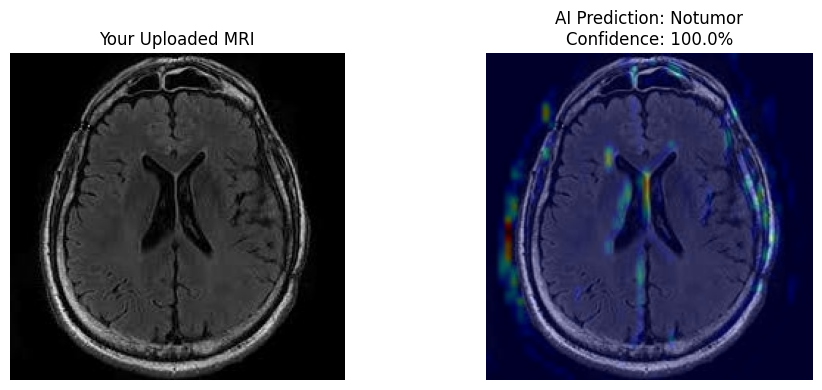

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.preprocessing.image import img_to_array
from google.colab import files
from PIL import Image
import io

print("👇 CLICK THE 'CHOOSE FILES' BUTTON BELOW TO UPLOAD YOUR MRI")
uploaded = files.upload()

for fn in uploaded.keys():
    # 1. Load the image you just uploaded
    img = Image.open(io.BytesIO(uploaded[fn])).convert('RGB')
    img_resized = img.resize((224, 224))
    img_array = img_to_array(img_resized)
    img_array_batch = np.expand_dims(img_array, axis=0)

    # 2. Ask the AI to predict
    predictions = model.predict(img_array_batch)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_idx]
    confidence = np.max(predictions[0]) * 100

    # 3. Generate the Heatmap
    heatmap = make_gradcam_heatmap(img_array_batch, model, last_conv_layer_name)

    # 4. Colorize and Superimpose
    heatmap_rescaled = np.uint8(255 * heatmap)
    jet = cm.jet(np.arange(256))[:, :3]
    jet_heatmap = jet[heatmap_rescaled]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img_array.shape[1], img_array.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
    superimposed_img = jet_heatmap * 0.4 + img_array
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    # 5. Show the Results!
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Your Uploaded MRI")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"AI Prediction: {predicted_class_name.capitalize()}\nConfidence: {confidence:.1f}%")
    plt.axis('off')

    plt.tight_layout()
    plt.show()